# 平面 2R 串联机器人：符号运动学、微分运动与静力映射

沿用原代码的 `l[0], l[1], q[0], q[1]`：两个关节均为绕 $+z$ 轴的转动关节，
$q_0$ 从基坐标系 $+x$ 轴逆时针计量，$q_1$ 是第二杆相对第一杆的角度。
连杆长度 $l_0,l_1>0$，角度使用 **rad**；数值例中长度为 m，力为 N，力矩为 N·m。
末端点位于第二杆尖端，所有位置、速度和力的分量均在**基坐标系**表达；末端力矩绕该末端点计量。

本例分别讨论位置 $\mathbf p=[x,y]^T$ 和平面位姿 $\boldsymbol\eta=[x,y,\phi]^T$，其中
$\phi=q_0+q_1$。两个自由度不能独立指定三个任意位姿分量。
逆运动学不施加关节限位、碰撞约束，角度解按 $2\pi$ 周期理解。

从上到下运行全部单元即可。需要 `sympy`、`numpy`、`matplotlib` 和 Jupyter/IPython；
后半部分给出可直接调用的数值函数、两组逆解图，以及符号和有限差分验证。

In [1]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from IPython.display import display, Math

sy.init_printing()
np.set_printoptions(precision=6, suppress=True)


def show_math(lhs, rhs):
    """把 SymPy 标量、矩阵或张量显示为 LaTeX 等式。"""
    display(Math(lhs + ' = ' + sy.latex(rhs)))


l = sy.symbols('l_0:2', positive=True)
q = sy.symbols('q_0:2', real=True)
q_vec = sy.Matrix(q)
dq = sy.Matrix(sy.symbols('dq_0:2', real=True))       # 关节速度
ddq = sy.Matrix(sy.symbols('ddq_0:2', real=True))     # 关节加速度
delta_q = sy.Matrix(sy.symbols('delta_q_0:2', real=True))  # 小位移，不是速度
x_d, y_d = sy.symbols('x_d y_d', real=True)

## 1. 正运动学

平面齐次变换采用 $3\times3$ 的 $SE(2)$ 表示：
$T_{0E}=T_{01}T_{1E}$，每段变换均为“先绕局部 $z$ 轴转动，再沿新的 $x$ 轴平移”。
矩阵左上角为二维旋转，最后一列为末端位置。

In [2]:
def planar_transform(theta, length):
    return sy.Matrix([
        [sy.cos(theta), -sy.sin(theta), length * sy.cos(theta)],
        [sy.sin(theta),  sy.cos(theta), length * sy.sin(theta)],
        [0,              0,             1],
    ])


T_01 = planar_transform(q[0], l[0])
T_1E = planar_transform(q[1], l[1])
T_0E = sy.trigsimp(T_01 * T_1E)

x = l[0] * sy.cos(q[0]) + l[1] * sy.cos(q[0] + q[1])
y = l[0] * sy.sin(q[0]) + l[1] * sy.sin(q[0] + q[1])
phi = q[0] + q[1]
p = sy.Matrix([x, y])
pose = sy.Matrix([x, y, phi])

show_math(r'\mathbf{p}', p)
show_math(r'\phi', phi)
show_math(r'T_{0E}', T_0E)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. 位置逆运动学：两个分支与工作空间

给定目标 $(x_d,y_d)$，令
$c=(x_d^2+y_d^2-l_0^2-l_1^2)/(2l_0l_1)$，$s_\sigma=\sigma\sqrt{1-c^2}$，$\sigma\in\{+1,-1\}$。
使用 `atan2` 保留象限信息，两分支分别对应 $\sin q_1$ 的正负。

可达条件是 $|l_0-l_1|\le\sqrt{x_d^2+y_d^2}\le l_0+l_1$，等价于 $|c|\le1$。
一般内部点有两组解；工作空间边界上两分支合并（按 $2\pi$ 等价）。
特殊地，若 $l_0=l_1$ 且目标为原点，则 $q_1=\pi\pmod{2\pi}$、$q_0$ 任意，存在无穷多解，
此时不能使用含 `atan2(0, 0)` 的通式。

若同时要求末端方向 $\phi_d$，还必须检查所选解的 $q_0+q_1\equiv\phi_d\pmod{2\pi}$；
位置可达不代表任意给定方向也可达。

### 从目标点 $[x_d,y_d]$ 出发，怎样用高中数学算出两个关节角？

可以。这一节的 **位置逆运动学（IK）只需要勾股定理、余弦定理和三角函数，不需要求导或 Jacobian**。
正运动学是“已知角度求位置”，逆运动学则是“已知目标位置求角度”。
这里把已知的目标写成 $\mathbf p_d=[x_d,y_d]^T$，要求出 $q_0,q_1$，使 $\mathbf p(q_0,q_1)=\mathbf p_d$。
注意：$q_0$ 是第一杆相对水平轴的角度，$q_1$ 是第二杆相对第一杆的角度，第二杆相对水平轴的角度才是 $q_0+q_1$。

**第 1 步：求目标到基座的距离，先判断够不够得着。**

设基座为 $O$，两杆连接处为 $A$，目标点为 $P$。三角形 $OAP$ 的三条边分别为 $l_0,l_1,r$，其中

$$r=\sqrt{x_d^2+y_d^2}.$$

由三角形边长关系，必须满足 $|l_0-l_1|\le r\le l_0+l_1$。等号对应两杆共线；若不满足，就没有实数角度解。

**第 2 步：把正运动学的两个式子平方后相加，先消掉 $q_0$。**

$$\begin{aligned}
x_d&=l_0\cos q_0+l_1\cos(q_0+q_1),\\
y_d&=l_0\sin q_0+l_1\sin(q_0+q_1).
\end{aligned}$$

利用 $\sin^2\theta+\cos^2\theta=1$ 和
$\cos a\cos b+\sin a\sin b=\cos(a-b)$，得到

$$\begin{aligned}
x_d^2+y_d^2
&=l_0^2+l_1^2+2l_0l_1\big[\cos q_0\cos(q_0+q_1)+\sin q_0\sin(q_0+q_1)\big]\\
&=l_0^2+l_1^2+2l_0l_1\cos q_1.
\end{aligned}$$

于是

$$\boxed{c=\cos q_1=\frac{x_d^2+y_d^2-l_0^2-l_1^2}{2l_0l_1}}.$$

这也可以由余弦定理得到。注意三角形在 $A$ 点的内角是 $\overrightarrow{AO}$ 与 $\overrightarrow{AP}$ 的夹角，
而关节角是从第一杆的方向 $\overrightarrow{OA}$ 转到第二杆方向 $\overrightarrow{AP}$ 的角度；
二者的角度约定不同，所以这里是 **$+2l_0l_1\cos q_1$**。

**第 3 步：由余弦求第二关节角，保留两个弯曲方向。**

当 $|c|<1$ 时，$q_1=+\arccos c$ 和 $q_1=-\arccos c$ 都成立，对应两种弯曲构型。
代码把这两种选择写成

$$s_\sigma=\sin q_1=\sigma\sqrt{1-c^2},\qquad
q_1^{(\sigma)}=\operatorname{atan2}(s_\sigma,c),\qquad \sigma\in\{+1,-1\}.$$

`atan2(y, x)` 可以理解为“从向量的横、纵坐标求它的方向角”，即带象限判断的反正切。
它比直接写 $\arctan(y/x)$ 多保留了象限信息，也能处理 $x=0,y\ne0$ 的情况。
例如 $(x,y)=(1,1)$ 和 $(-1,-1)$ 的 $y/x$ 都是 $1$，但它们的方向分别为 $45^\circ$ 和 $-135^\circ$。

**第 4 步：目标方向减去两杆之间的几何偏角，求第一关节角。**

从基座看目标，方向角为

$$\alpha=\operatorname{atan2}(y_d,x_d).$$

先想象把整个机器人转到“第一杆沿水平正方向”的位置，也就是暂时令 $q_0=0$。
此时第一杆贡献 $(l_0,0)$，第二杆贡献 $(l_1\cos q_1,l_1\sin q_1)$，所以末端坐标是

$$u=l_0+l_1\cos q_1=l_0+l_1c,\qquad v=l_1\sin q_1=l_1s_\sigma.$$

此时末端相对第一杆的方向角为 $\beta=\operatorname{atan2}(v,u)$。
把机器人整体转回 $q_0$ 后，目标方向满足 $\alpha=q_0+\beta$（按 $2\pi$ 周期理解），因此

$$\boxed{q_0^{(\sigma)}=\operatorname{atan2}(y_d,x_d)
-\operatorname{atan2}\!\left(l_1s_\sigma,\;l_0+l_1c\right)}.$$

**第 5 步：两个正负号分别算一遍，并代回正运动学检查。**

例如 $l_0=l_1=1$，目标 $[x_d,y_d]=[1,1]$：
$r^2=2$，$c=0$，$\alpha=45^\circ$。

| 分支 | $s_\sigma$ | $q_1$ | $\beta$ | $q_0=\alpha-\beta$ |
|---|---:|---:|---:|---:|
| $\sigma=+1$ | $+1$ | $90^\circ$ | $45^\circ$ | $0^\circ$ |
| $\sigma=-1$ | $-1$ | $-90^\circ$ | $-45^\circ$ | $90^\circ$ |

所以两组解是 $(q_0,q_1)=(0,\pi/2)$ 和 $(\pi/2,-\pi/2)$。
第一组代回得到 $x=\cos0+\cos(\pi/2)=1$、$y=\sin0+\sin(\pi/2)=1$；
第二组代回得到 $x=\cos(\pi/2)+\cos0=1$、$y=\sin(\pi/2)+\sin0=1$。
表中用角度方便阅读，下面代码使用弧度。

对应下一单元代码的顺序就是：`c_ik` 求 $\cos q_1$ → `s_branch` 选择正负分支 →
两个 `atan2` 的差求 $q_0$ → `atan2(s_branch, c_ik)` 求 $q_1$。
在 $|c|=1$ 的一般边界上两分支合并；若 $l_0=l_1$ 且目标是原点，则 $q_1=\pi\pmod{2\pi}$、$q_0$ 任意，
不能对零向量使用 `atan2(0, 0)`，需要按前面说明单独处理。


In [3]:
c_ik = (x_d**2 + y_d**2 - l[0]**2 - l[1]**2) / (2 * l[0] * l[1])
ik_branches = {}
for sign in (1, -1):
    s_branch = sign * sy.sqrt(1 - c_ik**2)
    ik_branches[sign] = sy.Matrix([
        sy.atan2(y_d, x_d) - sy.atan2(l[1] * s_branch, l[0] + l[1] * c_ik),
        sy.atan2(s_branch, c_ik),
    ])
q_ik_plus, q_ik_minus = ik_branches[1], ik_branches[-1]

# 显示紧凑形式；ik_branches 中保存已展开 c 的完整符号表达式。
c_symbol, s_symbol = sy.symbols('c s_sigma', real=True)
show_math('c', c_ik)
show_math(r'\mathbf{q}^{(\sigma)}', sy.Matrix([
    sy.atan2(y_d, x_d) - sy.atan2(l[1] * s_symbol, l[0] + l[1] * c_symbol),
    sy.atan2(s_symbol, c_symbol),
]))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 数值迭代法求 IK：从一个初始姿态开始，逐步修正位置误差

解析法直接给出角度公式；数值迭代法则反复做“**猜角度 → 算末端位置 → 看误差 → 小幅修正角度**”，
直到末端足够接近目标。它只需要能够计算正运动学和 Jacobian，因此也适用于难以写出解析逆解的机器人。
下面仍以位置目标 $\mathbf p_d=[x_d,y_d]^T$ 为例，角度在计算中一律使用 rad。

**1. 先定义要消除的误差。**

把正运动学看成函数

$$\mathbf p(\mathbf q)=\begin{bmatrix}
l_0\cos q_0+l_1\cos(q_0+q_1)\\
l_0\sin q_0+l_1\sin(q_0+q_1)
\end{bmatrix},\qquad \mathbf q=\begin{bmatrix}q_0\\q_1\end{bmatrix}.$$

第 $k$ 次迭代的角度估计为 $\mathbf q^{(k)}$，当前位置误差定义为

$$\boxed{\mathbf e^{(k)}=\mathbf p_d-\mathbf p(\mathbf q^{(k)})}.$$

例如 $\mathbf e=[0.02,-0.01]^T$ 表示末端还需要向 $+x$ 移动 $0.02$ m、向 $-y$ 移动 $0.01$ m。
目标是让误差长度 $\|\mathbf e\|=\sqrt{e_x^2+e_y^2}$ 小于指定容差。

**2. 用 Jacobian 把“位置修正”换成“角度修正”。**

在当前姿态附近，角度变化很小时，一阶近似为

$$\mathbf p(\mathbf q^{(k)}+\Delta\mathbf q)
\approx \mathbf p(\mathbf q^{(k)})+J(\mathbf q^{(k)})\Delta\mathbf q.$$

$J$ 的每一列表示“只改变对应关节一点点，末端会向哪里移动”。为了让新的末端位置接近目标，令

$$\boxed{J(\mathbf q^{(k)})\Delta\mathbf q\approx\mathbf e^{(k)}}.$$

这就是迭代的关键：原本的三角函数方程，在当前姿态附近变成了一组关于 $\Delta\mathbf q$ 的线性方程。
它只是局部近似，所以更新角度后必须重新计算位置和 Jacobian，通常不能只算一次。

**3. 求出本次角度修正：牛顿法、伪逆与阻尼。**

对于本例的 $2\times2$ 位置 Jacobian，若 $J$ 非奇异，可以使用求根的牛顿法：

$$\Delta\mathbf q=J^{-1}\mathbf e,\qquad
\mathbf q^{(k+1)}=\mathbf q^{(k)}+\alpha\Delta\mathbf q,\qquad 0<\alpha\le1.$$

实际编程时用 `np.linalg.solve(J, e)` 解方程，不必显式计算逆矩阵。
$\alpha=1$ 表示接受整个修正量；较小的 $\alpha$ 表示先走一部分，避免局部近似不准时走得太远。
这里是在求解方程 $\mathbf p(\mathbf q)=\mathbf p_d$，只需要 Jacobian，不需要 Hessian。

如果 $J$ 不是方阵或不可逆，可用伪逆 $\Delta\mathbf q=J^+\mathbf e$，
得到**线性化问题**的最小二乘解；但它不保证一步消除真实误差，而且接近奇异位形时可能产生很大的角度修正。
更常用的稳定处理是**阻尼最小二乘法**：

$$\min_{\Delta\mathbf q}\left(\|J\Delta\mathbf q-\mathbf e\|^2
+\lambda^2\|\Delta\mathbf q\|^2\right),\qquad \lambda>0.$$

第一项希望末端补上位置误差，第二项限制关节修正量过大。它对应的线性方程是

$$\boxed{(J^TJ+\lambda^2I)\Delta\mathbf q=J^T\mathbf e}.$$

代码形式为 `np.linalg.solve(J.T @ J + lam**2 * np.eye(2), J.T @ e)`。
$\lambda$ 越大，越倾向于较小的修正，但可能收敛更慢；$\lambda$ 应结合长度单位和机器人尺度选择。
$\lambda$ 控制修正量的求解，$\alpha$ 控制实际执行这一步的比例，两者作用不同。

**4. 按以下流程循环，并检查实际误差是否下降。**

1. 用 $|l_0-l_1|\le\sqrt{x_d^2+y_d^2}\le l_0+l_1$ 检查位置可达性。
2. 选初始角度 $\mathbf q^{(0)}$，例如机器人的当前角度；设置位置容差 $\varepsilon_p$ 和最大迭代次数。
3. 计算当前位置及误差；若 $\|\mathbf e\|\le\varepsilon_p$，返回当前角度并报告成功。
4. 在**当前角度**重新计算 $J$，解上面的阻尼方程，得到 $\Delta\mathbf q$。
5. 先取 $\alpha=1$，计算候选角度 $\mathbf q_{\rm trial}=\mathbf q+\alpha\Delta\mathbf q$，并用正运动学计算候选位置。
6. 若实际误差变小，接受该候选；否则将 $\alpha$ 减半后重试。这称为回溯步长。
7. 若步长已很小仍无法减小误差，报告停滞；否则继续下一轮。达到迭代次数上限时，再检查最终误差并报告是否成功。

```text
q ← 初始角度
重复，直到达到最大迭代次数：
    e ← 目标位置 - 正运动学(q)
    若 ||e|| ≤ 位置容差：返回 q，成功
    J ← 当前 q 处的 Jacobian
    解 (JᵀJ + λ²I) Δq = Jᵀe
    α ← 1
    不断尝试 q_trial = q + α Δq，若误差不下降就把 α 减半
    若 α 小于允许的下限：返回 q，停滞（未达到位置容差）
    q ← q_trial
根据最终的位置误差，返回成功或未收敛
```

“角度变化很小”不等于“已经到达目标”。判断成功的主要依据是**末端位置误差**，
而小步长、无法下降或达到次数上限是停止尝试的理由，不应自动标记为成功。

**5. 一个实际迭代例子。**

取 $l_0=l_1=1$ m、目标 $[1,1]^T$ m、初值 $(q_0,q_1)=(20^\circ,60^\circ)$，
使用阻尼参数 $\lambda=0.05$（对应本例的 m/rad 数值尺度）、位置容差 $10^{-6}$ m。
下面每一行均重新计算正运动学和 Jacobian；本例的每次完整步长 $\alpha=1$ 都能减小误差。

| 迭代 $k$ | $q_0$（度） | $q_1$（度） | 当前 $x$（m） | 当前 $y$（m） | $\|\mathbf e\|$（m） |
|---|---:|---:|---:|---:|---:|
| 0 | 20.000000 | 60.000000 | 1.11334080 | 1.32682790 | $3.4592\times10^{-1}$ |
| 1 | -2.339106 | 96.560837 | 0.92555032 | 0.95647287 | $8.6240\times10^{-2}$ |
| 2 | -0.171369 | 90.218964 | 0.99916483 | 0.99700871 | $3.1057\times10^{-3}$ |
| 3 | -0.000986 | 90.001781 | 0.99998612 | 0.99998279 | $2.2110\times10^{-5}$ |
| 4 | -0.000007 | 90.000011 | 0.99999992 | 0.99999988 | $1.4282\times10^{-7}$ |

四次更新后误差已小于容差，得到约 $(q_0,q_1)=(0,\pi/2)$，与前面的一组解析逆解一致。
表中角度只为方便阅读；计算时使用弧度，表中误差由未舍入的数值计算。

**6. 初值和奇异位形为什么重要？**

- 不同初值可能收敛到不同 IK 分支，也可能不收敛；一次迭代求解通常只能得到一组解，不能保证找全所有解。
- 阻尼能改善线性方程求解的稳定性，但不能保证一定找到目标。例如 $l_0=l_1=1$、初值 $(0,0)$ 完全伸直、
  目标为 $(1.5,0)$ 时，当前误差为 $(-0.5,0)^T$，而
  $J=\begin{bmatrix}0&0\\2&1\end{bmatrix}$，所以 $J^T\mathbf e=0$，阻尼法也会给出 $\Delta\mathbf q=0$。
  目标明明可达，迭代却停住了，因为这个姿态下的一阶运动只能沿 $y$ 方向。可改用稍微弯曲的初值，或尝试多个初值。
- 跟踪连续目标时，可以把上一次求出的关节角作为下一次的初值，通常更容易得到连续的关节运动。
  若还存在关节限位，需要把限位作为额外约束处理；单靠上述位置误差迭代并不保证满足限位。


## 3. Jacobian 与奇异位形

位置 Jacobian 为 $J=\partial\mathbf p/\partial\mathbf q\in\mathbb R^{2\times2}$。
完整平面位姿的 Jacobian 为 $J_\eta=\partial\boldsymbol\eta/\partial\mathbf q\in\mathbb R^{3\times2}$，
其最后一行把关节角速度映射到末端角速度。

$\det J=l_0l_1\sin q_1$：当 $q_1=k\pi$ 时位置映射奇异，两个方向的瞬时平移不能独立控制。
这并不意味着 $J_\eta$ 降秩；在 $l_0>0$ 时它始终列满秩，但其可实现的位姿速度仍只有二维。

In [4]:
J = p.jacobian(q_vec)
J_pose = pose.jacobian(q_vec)
det_J = sy.trigsimp(J.det())

show_math('J', J)
show_math(r'J_\eta', J_pose)
show_math(r'\det J', det_J)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 4. Hessian：每个输出分量对应一个矩阵

向量值函数没有单个普通二维 Hessian。这里采用索引约定
$H_{aij}=\partial^2 p_a/(\partial q_i\partial q_j)$：
`H[a, i, j]` 的第一个索引是输出分量，后两个索引是关节。
`H_x`、`H_y` 分别是 $2\times2$ 矩阵，`H` 的形状是 $(2,2,2)$。
位姿 Hessian `H_pose` 的形状为 $(3,2,2)$，其中方向分量的 Hessian 为零矩阵。

In [5]:
H_x = sy.hessian(x, q_vec)
H_y = sy.hessian(y, q_vec)
H_phi = sy.hessian(phi, q_vec)
H_components = (H_x, H_y)
H = sy.ImmutableDenseNDimArray([h.tolist() for h in H_components])
H_pose = sy.ImmutableDenseNDimArray([h.tolist() for h in (H_x, H_y, H_phi)])

show_math('H_x', H_x)
show_math('H_y', H_y)
show_math(r'H_\phi', H_phi)
print('H.shape =', H.shape, '; H_pose.shape =', H_pose.shape)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

H.shape = (2, 2, 2) ; H_pose.shape = (3, 2, 2)


## 5. 关节微分、速度与加速度

微分关系 $d\mathbf p=J\,d\mathbf q$ 是精确的线性切映射；有限小增量则满足

$$\mathbf p(\mathbf q+\Delta\mathbf q)=\mathbf p(\mathbf q)+J\Delta\mathbf q
+\frac12\begin{bmatrix}\Delta\mathbf q^T H_x\Delta\mathbf q\\
\Delta\mathbf q^T H_y\Delta\mathbf q\end{bmatrix}+O(\|\Delta\mathbf q\|^3).$$

沿轨迹对时间求导：
$\dot{\mathbf p}=J\dot{\mathbf q}$，
$\dot{\boldsymbol\eta}=J_\eta\dot{\mathbf q}$，
$\ddot{\mathbf p}=J\ddot{\mathbf q}+\dot J\dot{\mathbf q}$。
其中 $\dot J=\sum_k(\partial J/\partial q_k)\dot q_k$，
且 $(\dot J\dot{\mathbf q})_a=\dot{\mathbf q}^TH_a\dot{\mathbf q}$。
姿态满足 $\dot\phi=\dot q_0+\dot q_1$、$\ddot\phi=\ddot q_0+\ddot q_1$。

In [6]:
delta_p_linear = J * delta_q
delta_p_quadratic = sy.Matrix([(delta_q.T * h * delta_q)[0] for h in H_components])
p_taylor_2 = p + delta_p_linear + delta_p_quadratic / 2

J_dot = sum((J.diff(q[k]) * dq[k] for k in range(2)), sy.zeros(2, 2))
v = J * dq
twist = J_pose * dq
convective_acceleration = sy.Matrix([(dq.T * h * dq)[0] for h in H_components])
a = J * ddq + convective_acceleration
pose_acceleration = sy.Matrix.vstack(a, sy.Matrix([ddq[0] + ddq[1]]))

show_math(r'\dot{\mathbf{p}}', v)
show_math(r'\dot{J}', J_dot)
show_math(r'\ddot{\mathbf{p}}', sy.expand(a))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 6. 局部逆微分与逆运动学 Hessian

在 **$\sin q_1\ne0$ 且固定一个逆解分支** 时，记 $A=J^{-1}$，则

$$d\mathbf q=A\,d\mathbf p,\qquad
\dot{\mathbf q}=A\dot{\mathbf p},\qquad
\ddot{\mathbf q}=A\left(\ddot{\mathbf p}-\dot J\dot{\mathbf q}\right).$$

逆映射的 Hessian 为
$$K_i=\frac{\partial^2q_i}{\partial\mathbf p^2}
=-A^T\left(\sum_{a=0}^{1}A_{ia}H_a\right)A,$$
因此也可写成 $\ddot q_i=(A\ddot{\mathbf p})_i+\dot{\mathbf p}^TK_i\dot{\mathbf p}$。
以下 `H_ik` 保留以 $q$ 表达的局部逆 Hessian；代入 `ik_branches[sign]` 即得到该分支上以目标位置表达的形式。
它只对角度的连续局部分支求导，不跨越角度换支或奇异点。

奇异点处不可使用 $J^{-1}$。伪逆只能给出最小二乘解，目标速度是否可实现仍需检查 $J\dot q-\dot p$ 的残差。
对于完整位姿速度，必须同时满足 $\dot\phi=\dot q_0+\dot q_1$，不能独立指定三个任意速度分量。

In [7]:
# 2×2 伴随矩阵形式，避免一般符号求逆产生冗长表达式。
J_inv = (J.adjugate() / det_J).applyfunc(sy.trigsimp)
v_desired = sy.Matrix(sy.symbols('v_x v_y', real=True))
a_desired = sy.Matrix(sy.symbols('a_x a_y', real=True))
dq_from_v = J_inv * v_desired
# 此式中的 dq 是当前关节速度；给定末端速度时可代入 dq_from_v。
ddq_from_a = J_inv * (a_desired - convective_acceleration)

H_ik_components = tuple(
    -J_inv.T * sum((J_inv[i, k] * H_components[k] for k in range(2)), sy.zeros(2, 2)) * J_inv
    for i in range(2)
)
H_ik = sy.ImmutableDenseNDimArray([h.tolist() for h in H_ik_components])
dq_from_v_compact = dq_from_v.applyfunc(sy.trigsimp)

show_math(r'J^{-1}', J_inv)
show_math(r'\dot{\mathbf q}', dq_from_v_compact)
print('H_ik.shape =', H_ik.shape, '(仅适用于非奇异的局部逆映射)')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

H_ik.shape = (2, 2, 2) (仅适用于非奇异的局部逆映射)


## 7. 末端力 / 力矩与关节力矩：虚功对偶

令 $\mathbf w=[F_x,F_y,M_z]^T$ 表示作用在机器人末端的外部平面力旋量，
其中 $M_z$ 是**绕末端点**的力矩。其等效关节广义力为

$$\boldsymbol\tau_{\rm ext}=J_\eta^T\mathbf w
=J^T\begin{bmatrix}F_x\\F_y\end{bmatrix}+\begin{bmatrix}1\\1\end{bmatrix}M_z.$$

由虚功或瞬时功率守恒：
$\boldsymbol\tau_{\rm ext}^T\dot{\mathbf q}=\mathbf w^T\dot{\boldsymbol\eta}$。
这是外力的广义力映射；忽略重力、惯性和摩擦时，**静止平衡所需的驱动关节力矩**为
$\boldsymbol\tau_{\rm act}=-\boldsymbol\tau_{\rm ext}$。
若把 $\mathbf w$ 定义为机器人施加给环境的力旋量，则所需驱动力矩的符号相反，即 $\boldsymbol\tau_{\rm act}=J_\eta^T\mathbf w$。
此处不推导质量矩阵、重力或完整动力学。

当 $M_z=0$ 且 $J$ 非奇异时，可以由 $\boldsymbol\tau_{\rm ext}$ 唯一恢复平移力：
$\mathbf F=J^{-T}\boldsymbol\tau_{\rm ext}$。
若已知 $M_z$，则 $\mathbf F=J^{-T}(\boldsymbol\tau_{\rm ext}-[M_z,M_z]^T)$。
若 $F_x,F_y,M_z$ 均未知，两个关节力矩无法唯一确定三个末端载荷分量；
任意 $\mathbf w+\lambda\mathbf n$ 都产生相同关节力矩，其中 $J_\eta^T\mathbf n=0$。

In [8]:
F_x, F_y, M_z = sy.symbols('F_x F_y M_z', real=True)
F = sy.Matrix([F_x, F_y])
wrench = sy.Matrix([F_x, F_y, M_z])
tau_ext = J_pose.T * wrench
tau_act_static = -tau_ext
tau_force_only = J.T * F
tau_symbols = sy.Matrix(sy.symbols('tau_0:2', real=True))
F_from_tau = J_inv.T * tau_symbols
F_from_tau_known_moment = J_inv.T * (tau_symbols - sy.ones(2, 1) * M_z)

# J_pose 的两列叉乘给出 J_pose.T 的零空间方向；任意位形均成立。
wrench_null = sy.trigsimp(J_pose[:, 0].cross(J_pose[:, 1]))
lambda_w = sy.symbols('lambda_w', real=True)
# 下面这个特解依赖 J_inv，故该通解表示仅在位置 J 非奇异时使用。
wrench_particular = sy.Matrix.vstack(F_from_tau, sy.Matrix([0]))
wrench_family = wrench_particular + lambda_w * wrench_null

show_math(r'\boldsymbol\tau_{\rm ext}', tau_ext)
show_math(r'\mathbf F\; (M_z=0)', F_from_tau)
show_math(r'\mathbf n', wrench_null)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 8. 可直接调用的数值函数

以下函数的参数顺序统一为 `(q0, q1, l0, l1, ...)`。
`inverse_kinematics(x_target, y_target, l0, l1)` 返回形状为 `(解的数量, 2)` 的数组，角度归一化到 $[-\pi,\pi)$。
它校验长度和可达性，只在浮点容差范围内把余弦截回 $[-1,1]$；边界解去重。
对于等长连杆到原点的连续无穷多解，显式抛出异常并给出解族，避免误报为两组离散解。

In [9]:
numeric_args = (*q, *l)
fk_num = sy.lambdify(numeric_args, p, modules='numpy', cse=True)
pose_num = sy.lambdify(numeric_args, pose, modules='numpy', cse=True)
jacobian_num = sy.lambdify(numeric_args, J, modules='numpy', cse=True)
pose_jacobian_num = sy.lambdify(numeric_args, J_pose, modules='numpy', cse=True)
hessian_num = sy.lambdify(numeric_args, [H_x, H_y], modules='numpy', cse=True)
inverse_hessian_num = sy.lambdify(numeric_args, list(H_ik_components), modules='numpy', cse=True)
velocity_num = sy.lambdify((*numeric_args, *dq), v, modules='numpy', cse=True)
acceleration_num = sy.lambdify((*numeric_args, *dq, *ddq), a, modules='numpy', cse=True)
wrench_to_tau_num = sy.lambdify((*numeric_args, F_x, F_y, M_z), tau_ext, modules='numpy', cse=True)


def wrap_angle(angle):
    return (np.asarray(angle) + np.pi) % (2 * np.pi) - np.pi


def inverse_kinematics(x_target, y_target, l0, l1, tol=1e-10):
    """返回平面 2R 位置逆解；tol 是相对长度及分支去重的数值容差。"""
    values = np.asarray([x_target, y_target, l0, l1, tol], dtype=float)
    if not np.all(np.isfinite(values)):
        raise ValueError('输入必须是有限实数。')
    x_target, y_target, l0, l1, tol = values
    if l0 <= 0 or l1 <= 0:
        raise ValueError('连杆长度必须严格大于 0。')
    if not 0 < tol < 1:
        raise ValueError('tol 必须位于 (0, 1)。')
    radius = np.hypot(x_target, y_target)
    length_scale = max(l0, l1)
    if not np.isfinite(radius):
        raise ValueError('目标距离超出浮点数范围。')
    if radius == 0.0 and l0 == l1:
        raise ValueError('无穷多解：q1 = pi (mod 2*pi)，q0 任意。')
    if radius < abs(l0 - l1) - tol * length_scale or radius > l0 + l1 + tol * length_scale:
        raise ValueError('目标不可达：必须满足 |l0-l1| <= r <= l0+l1。')

    # 用相对长度计算余弦，减少平方运算的数值范围问题。
    L0, L1, R = l0 / length_scale, l1 / length_scale, radius / length_scale
    lower, upper = abs(L0 - L1), L0 + L1
    if abs(R - upper) <= tol:
        cos_q1, sin_magnitude = 1.0, 0.0
    elif lower > 0 and abs(R - lower) <= tol:
        cos_q1, sin_magnitude = -1.0, 0.0
    else:
        cos_q1 = np.clip((R * R - L0 * L0 - L1 * L1) / (2 * L0 * L1), -1.0, 1.0)
        # 因式分解的三角形面积公式，比 sqrt(1-cos_q1**2) 更能保留
        # 等长连杆接近原点时的小量；原点本身已在前面单独处理。
        area_product = (R - lower) * (R + lower) * (upper - R) * (upper + R)
        sin_magnitude = np.sqrt(max(0.0, area_product)) / (2 * L0 * L1)
    solutions = []
    for sign in (1, -1):
        sin_q1 = sign * sin_magnitude
        angle1 = np.arctan2(sin_q1, cos_q1)
        angle0 = np.arctan2(y_target, x_target) - np.arctan2(L1 * sin_q1, L0 + L1 * cos_q1)
        candidate = wrap_angle([angle0, angle1])
        if not any(np.all(np.abs(wrap_angle(candidate - previous)) <= tol) for previous in solutions):
            solutions.append(candidate)
    return np.asarray(solutions)

## 9. 数值示例：从位置、速度、加速度到载荷

只需修改下一单元的 `lengths`、`q_example`、`dq_example`、`ddq_example` 和 `wrench_example` 即可探索不同位形。
逆速度、逆加速度和逆力映射在本例非奇异位形使用 `np.linalg.solve`，避免显式求数值逆矩阵。

In [10]:
lengths = np.array([1.0, 0.7])
q_example = np.deg2rad([30.0, 60.0])
dq_example = np.array([0.2, -0.1])
ddq_example = np.array([0.05, 0.03])
wrench_example = np.array([4.0, -3.0, 0.5])
args_example = (*q_example, *lengths)

p_example = np.asarray(fk_num(*args_example), dtype=float).reshape(2)
solutions_example = inverse_kinematics(*p_example, *lengths)
J_example = np.asarray(jacobian_num(*args_example), dtype=float)
J_pose_example = np.asarray(pose_jacobian_num(*args_example), dtype=float)
H_example = np.asarray(hessian_num(*args_example), dtype=float)
v_example = J_example @ dq_example
twist_example = J_pose_example @ dq_example
quadratic_velocity = np.einsum('aij,i,j->a', H_example, dq_example, dq_example)
a_example = J_example @ ddq_example + quadratic_velocity
tau_example = J_pose_example.T @ wrench_example

dq_recovered = np.linalg.solve(J_example, v_example)
ddq_recovered = np.linalg.solve(J_example, a_example - quadratic_velocity)
F_recovered = np.linalg.solve(J_example.T, tau_example - wrench_example[2] * np.ones(2))

print('末端位置 [m]:', p_example)
print('两组位置逆解 [deg，仅为方便阅读]:\n', np.rad2deg(solutions_example))
print('末端 [vx, vy, omega_z]:', twist_example)
print('末端加速度 [m/s^2]:', a_example)
print('外载等效关节力矩 [N m]:', tau_example)
print('静止平衡的驱动力矩 [N m]:', -tau_example)
print('由末端速度恢复 dq [rad/s]:', dq_recovered)
print('由末端加速度恢复 ddq [rad/s^2]:', ddq_recovered)
print('已知 Mz 时恢复的末端力 [N]:', F_recovered)
print('关节功率 / 末端功率 [W]:', tau_example @ dq_example, wrench_example @ twist_example)

末端位置 [m]: [0.866025 1.2     ]
两组位置逆解 [deg，仅为方便阅读]:
 [[ 30.        60.      ]
 [ 78.364949 -60.      ]]
末端 [vx, vy, omega_z]: [-0.17      0.173205  0.1     ]
末端加速度 [m/s^2]: [-0.115641  0.016301]
外载等效关节力矩 [N m]: [-6.898076 -2.3     ]
静止平衡的驱动力矩 [N m]: [6.898076 2.3     ]
由末端速度恢复 dq [rad/s]: [ 0.2 -0.1]
由末端加速度恢复 ddq [rad/s^2]: [0.05 0.03]
已知 Mz 时恢复的末端力 [N]: [ 4. -3.]
关节功率 / 末端功率 [W]: -1.1496152422706634 -1.1496152422706631


### 两个逆解与位置工作空间

图中两个构型到达同一末端位置，但末端方向一般不同。虚线圆给出位置工作空间的内外边界。
图中文字使用英文，避免运行环境缺少中文字体导致图中文字丢失。

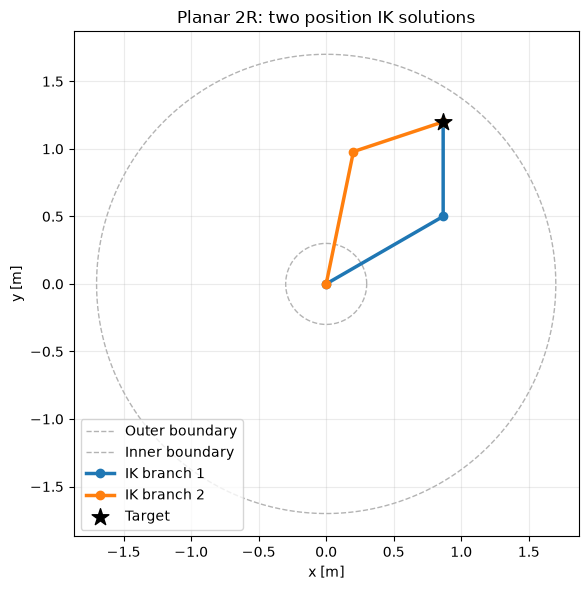

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
theta_plot = np.linspace(0, 2 * np.pi, 400)
for radius, label in [(sum(lengths), 'Outer boundary'), (abs(lengths[0] - lengths[1]), 'Inner boundary')]:
    ax.plot(radius * np.cos(theta_plot), radius * np.sin(theta_plot), '--', color='0.7', linewidth=1, label=label)

for i, angles in enumerate(solutions_example):
    elbow = lengths[0] * np.array([np.cos(angles[0]), np.sin(angles[0])])
    tip = np.asarray(fk_num(*angles, *lengths), dtype=float).reshape(2)
    points = np.vstack([np.zeros(2), elbow, tip])
    ax.plot(points[:, 0], points[:, 1], 'o-', linewidth=2.5, label=f'IK branch {i + 1}')

ax.scatter(*p_example, color='black', marker='*', s=160, zorder=5, label='Target')
ax.set(xlabel='x [m]', ylabel='y [m]', title='Planar 2R: two position IK solutions')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)
ax.legend(loc='lower left')
fig.tight_layout()
plt.show()

## 10. 验证：符号恒等式与独立数值差分

先检查变换、Hessian 对称性、加速度链式法则、逆 Jacobian 和虚功恒等式。
再用实际正 / 逆运动学的中心有限差分检查导数，而不是只比较由同一公式生成的两个函数。
数值测试还覆盖两组逆解的回代、工作空间内外边界、不可达目标、等长原点以及奇异位形。

In [12]:
def assert_symbolic_zero(expression):
    entries = list(expression) if isinstance(expression, sy.MatrixBase) else [expression]
    assert all(sy.trigsimp(sy.simplify(item)) == 0 for item in entries)


assert_symbolic_zero(T_0E[:2, 2] - p)
assert_symbolic_zero(det_J - l[0] * l[1] * sy.sin(q[1]))
for h in (*H_components, *H_ik_components):
    assert_symbolic_zero(h - h.T)
assert_symbolic_zero(J_dot * dq - convective_acceleration)
assert_symbolic_zero(J * J_inv - sy.eye(2))
assert_symbolic_zero((tau_ext.T * dq)[0] - (wrench.T * twist)[0])
assert_symbolic_zero(J_pose.T * wrench_null)

# 独立地对 p(q(t)) 求时间导数。
t = sy.symbols('t', real=True)
q_t = sy.Matrix([sy.Function('q0')(t), sy.Function('q1')(t)])
p_t = p.subs(dict(zip(q, q_t)))
time_substitutions = {
    **{sy.diff(q_t[i], t, 2): ddq[i] for i in range(2)},
    **{sy.diff(q_t[i], t): dq[i] for i in range(2)},
    **{q_t[i]: q[i] for i in range(2)},
}
assert_symbolic_zero(sy.diff(p_t, t).subs(time_substitutions, simultaneous=True) - v)
assert_symbolic_zero(sy.diff(p_t, t, 2).subs(time_substitutions, simultaneous=True) - a)
print('符号检查全部通过。')

符号检查全部通过。


In [13]:
def finite_difference_jacobian(function, point, step=1e-6):
    point = np.asarray(point, dtype=float)
    basis = np.eye(point.size)
    return np.column_stack([
        (function(point + step * e) - function(point - step * e)) / (2 * step)
        for e in basis
    ])


def finite_difference_hessian(function, point, step=1e-4):
    point = np.asarray(point, dtype=float)
    value = np.asarray(function(point), dtype=float)
    result = np.empty((value.size, point.size, point.size))
    basis = np.eye(point.size)
    for i, ei in enumerate(basis):
        result[:, i, i] = (function(point + step * ei) - 2 * value + function(point - step * ei)) / step**2
        for j in range(i):
            ej = basis[j]
            mixed = (function(point + step * (ei + ej)) - function(point + step * (ei - ej))
                     - function(point + step * (-ei + ej)) + function(point - step * (ei + ej))) / (4 * step**2)
            result[:, i, j] = result[:, j, i] = mixed
    return result


def position_at(angles):
    return np.asarray(fk_num(*angles, *lengths), dtype=float).reshape(2)


J_finite_difference = finite_difference_jacobian(position_at, q_example)
H_finite_difference = finite_difference_hessian(position_at, q_example)
np.testing.assert_allclose(J_example, J_finite_difference, rtol=1e-7, atol=1e-8)
np.testing.assert_allclose(H_example, H_finite_difference, rtol=1e-5, atol=1e-6)

# 目标附近固定选取与 q_example 连续的分支，并消除 +/-pi 的表示跳变。
def local_inverse_at(target):
    candidates = inverse_kinematics(*target, *lengths)
    offsets = wrap_angle(candidates - q_example)
    return q_example + offsets[np.argmin(np.linalg.norm(offsets, axis=1))]


K_example = np.asarray(inverse_hessian_num(*args_example), dtype=float)
np.testing.assert_allclose(finite_difference_jacobian(local_inverse_at, p_example), np.linalg.inv(J_example), rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(finite_difference_hessian(local_inverse_at, p_example), K_example, rtol=2e-5, atol=2e-6)
np.testing.assert_allclose(dq_recovered, dq_example, atol=1e-12)
np.testing.assert_allclose(ddq_recovered, ddq_example, atol=1e-12)
np.testing.assert_allclose(F_recovered, wrench_example[:2], atol=1e-12)
np.testing.assert_allclose(ddq_recovered, np.linalg.solve(J_example, a_example) + np.einsum('aij,i,j->a', K_example, v_example, v_example), atol=1e-12)
np.testing.assert_allclose(tau_example @ dq_example, wrench_example @ twist_example, atol=1e-12)

# 直接对时间轨迹做二阶差分验证加速度。
def position_on_trajectory(time):
    return position_at(q_example + dq_example * time + 0.5 * ddq_example * time**2)


time_step = 1e-3
a_finite_difference = (position_on_trajectory(time_step) - 2 * position_on_trajectory(0) + position_on_trajectory(-time_step)) / time_step**2
np.testing.assert_allclose(a_example, a_finite_difference, rtol=1e-5, atol=1e-7)

rng = np.random.default_rng(42)
for _ in range(20):
    test_lengths = rng.uniform(0.3, 1.5, 2)
    test_q = np.array([rng.uniform(-np.pi, np.pi), rng.choice([-1, 1]) * rng.uniform(0.2, np.pi - 0.2)])
    target = np.asarray(fk_num(*test_q, *test_lengths), dtype=float).reshape(2)
    solutions = inverse_kinematics(*target, *test_lengths)
    assert solutions.shape == (2, 2)
    for solution in solutions:
        reconstructed = np.asarray(fk_num(*solution, *test_lengths), dtype=float).reshape(2)
        np.testing.assert_allclose(reconstructed, target, atol=1e-10)

# 工作空间边界：两分支合并，包括第二杆比第一杆长的折叠构型。
for target, test_lengths in [([2.0, 0.0], [1.0, 1.0]), ([1.0, 0.0], [2.0, 1.0]), ([1.0, 0.0], [1.0, 2.0]),
                             ([1.7, 0.0], [1.0, 0.7]), ([0.3, 0.0], [1.0, 0.7]), ([0.3, 0.0], [0.7, 1.0])]:
    solutions = inverse_kinematics(*target, *test_lengths)
    assert solutions.shape == (1, 2)
    np.testing.assert_allclose(np.asarray(fk_num(*solutions[0], *test_lengths)).reshape(2), target, atol=1e-12)

# 接近等长原点但尚未到原点：仍是两组离散解，不能丢失微小的 sin(q1)。
near_origin_target = np.array([1e-8, 0.0])
near_origin_solutions = inverse_kinematics(*near_origin_target, 1.0, 1.0)
assert near_origin_solutions.shape == (2, 2)
for solution in near_origin_solutions:
    np.testing.assert_allclose(np.asarray(fk_num(*solution, 1.0, 1.0)).reshape(2), near_origin_target, atol=1e-14)


def assert_ik_error(arguments, message_fragment):
    try:
        inverse_kinematics(*arguments)
    except ValueError as error:
        assert message_fragment in str(error)
    else:
        raise AssertionError('预期抛出 ValueError。')


assert_ik_error((3.0, 0.0, 1.0, 0.7), '不可达')
assert_ik_error((0.1, 0.0, 1.0, 0.7), '不可达')
assert_ik_error((0.0, 0.0, 1.0, 1.0), '无穷多解')
assert_ik_error((1.0, 0.0, 0.0, 1.0), '严格大于')
assert_ik_error((np.nan, 0.0, 1.0, 1.0), '有限实数')

# q0=q1=0 时只能瞬时沿 y 平移：伪逆不能实现指定的 x 方向速度。
J_singular = np.asarray(jacobian_num(0.0, 0.0, *lengths), dtype=float)
J_pose_singular = np.asarray(pose_jacobian_num(0.0, 0.0, *lengths), dtype=float)
assert np.linalg.matrix_rank(J_singular) == 1
assert np.linalg.matrix_rank(J_pose_singular) == 2
unreachable_velocity = np.array([1.0, 0.0])
dq_least_squares = np.linalg.pinv(J_singular) @ unreachable_velocity
velocity_residual = J_singular @ dq_least_squares - unreachable_velocity
np.testing.assert_allclose(np.linalg.norm(velocity_residual), 1.0)

print('数值检查全部通过（Jacobian、正/逆 Hessian、加速度、载荷、20 组随机 IK 与边界情况）。')
print('Jacobian 最大有限差分误差:', np.max(np.abs(J_example - J_finite_difference)))
print('Hessian 最大有限差分误差:', np.max(np.abs(H_example - H_finite_difference)))
print('奇异点不可实现速度的残差范数:', np.linalg.norm(velocity_residual))

数值检查全部通过（Jacobian、正/逆 Hessian、加速度、载荷、20 组随机 IK 与边界情况）。
Jacobian 最大有限差分误差: 4.9520054723473095e-11
Hessian 最大有限差分误差: 4.44089210278689e-08
奇异点不可实现速度的残差范数: 1.0


## 11. 用 Taylor 误差观察 Hessian 的作用

下面沿固定关节方向减小扰动幅值，分别比较一阶和二阶位置近似。
在未受浮点误差主导的区间，一阶近似误差按 $O(h^2)$ 下降，加入 Hessian 后按 $O(h^3)$ 下降。

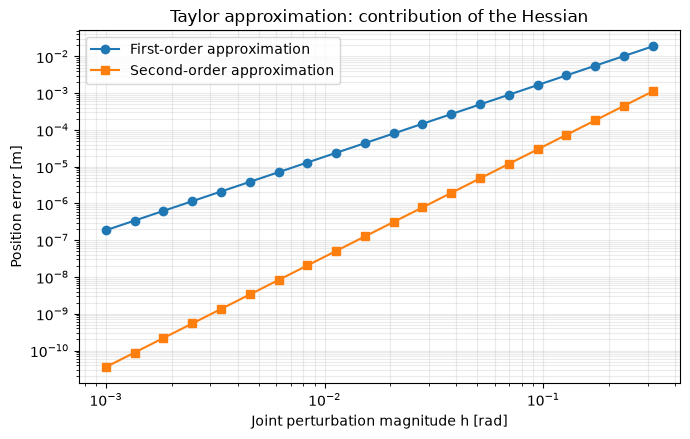

In [14]:
direction = np.array([0.6, -0.8])
step_sizes = np.logspace(-3, -0.5, 20)
linear_errors, quadratic_errors = [], []
for step in step_sizes:
    perturbation = step * direction
    exact = position_at(q_example + perturbation)
    first_order = p_example + J_example @ perturbation
    second_order = first_order + 0.5 * np.einsum('aij,i,j->a', H_example, perturbation, perturbation)
    linear_errors.append(np.linalg.norm(exact - first_order))
    quadratic_errors.append(np.linalg.norm(exact - second_order))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(step_sizes, linear_errors, 'o-', label='First-order approximation')
ax.loglog(step_sizes, quadratic_errors, 's-', label='Second-order approximation')
ax.set(xlabel='Joint perturbation magnitude h [rad]', ylabel='Position error [m]', title='Taylor approximation: contribution of the Hessian')
ax.grid(True, which='both', alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 常用变量速查

| 变量 / 函数 | 含义 |
|---|---|
| `p`, `pose`, `T_0E` | 位置、平面位姿与齐次变换 |
| `ik_branches[1]`, `ik_branches[-1]` | 两个位置逆运动学符号分支 |
| `J`, `J_pose`, `J_inv` | 位置、位姿 Jacobian 与非奇异位置逆 Jacobian |
| `H[a, i, j]`, `H_pose` | 正运动学位置 / 位姿 Hessian 张量 |
| `H_ik[i, a, b]` | 局部逆运动学 Hessian，以当前关节角表示 |
| `J_dot`, `v`, `twist`, `a` | Jacobian 时间导数、末端线速度、平面速度旋量、线加速度 |
| `delta_p_linear`, `p_taylor_2` | 一阶位置增量与二阶位置近似 |
| `dq_from_v`, `ddq_from_a` | 非奇异位形的逆速度与逆加速度关系 |
| `tau_ext`, `tau_act_static` | 外载等效关节力矩与忽略其他载荷的静平衡驱动力矩 |
| `F_from_tau_known_moment`, `wrench_family` | 已知末端力矩时恢复力，以及非唯一末端载荷族 |
| `fk_num`, `jacobian_num`, `hessian_num` | 可直接调用的 NumPy 数值函数 |
| `inverse_kinematics` | 带可达性、退化情况检查和边界去重的位置逆解函数 |